# 1. Problem Formulation


Optimizing training volume for muscle hypertrophy requires balancing the stimulus for muscle adaptation against the systemic fatigue generated by the workout. This project uses the Banister Fitness-Fatigue model to simulate a 12-week training block, aiming to mathematically identify the training frequency and volume that yields the highest net performance (hypertrophy) without overtraining.

# 2. Mathematical Theory

The physiological response to a training stressor is modeled using two competing exponential decay functions:

**Fitness ($Fitness(t)$):** Adapts slowly but persists longer.
$$Fitness(t) = Fitness(t-1) \cdot e^{-1/\tau_1} + Dose(t)$$

**Fatigue ($Fatigue(t)$):** Spikes quickly but dissipates rapidly.
$$Fatigue(t) = Fatigue(t-1) \cdot e^{-1/\tau_2} + Dose(t)$$

**Performance:** The net result.
$$Performance(t) = Fitness(t) - Fatigue(t)$$

### Variables and Constraints
* $\tau_1$: Time constant for fitness decay (typically ~45 days).
* $\tau_2$: Time constant for fatigue decay (typically ~15 days).
* **Assumptions:** This model assumes a linear physiological response to the training dose. It isolates training volume and does not account for external lifestyle constraints (e.g., sleep, caloric deficits).

# 3. Python Implementation & Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calc_decay(previous_value, tau, dose):
    """Calculates the daily value of fitness or fatigue based on exponential decay."""
    return previous_value * np.exp(-1 / tau) + dose

In [2]:
def simulate_training_block(days, tau1, tau2, doses):
    """Simulates a training block over a given number of days."""
    fitness = np.zeros(days)
    fatigue = np.zeros(days)
    performance = np.zeros(days)

    for t in range(1, days):
        fitness[t] = calc_decay(fitness[t-1], tau1, doses[t])
        fatigue[t] = calc_decay(fatigue[t-1], tau2, doses[t])
        performance[t] = fitness[t] - fatigue[t]

    return fitness, fatigue, performance

days = 84
standard_doses = np.zeros(days)
standard_doses[::3] = 50

In [3]:
assert calc_decay(100, 15, 0) < 100, "Error: Value should decrease with 0 dose"
assert calc_decay(10, 15, 50) > 10, "Error: Value should increase with high dose"
print("All unit tests passed successfully.")

All unit tests passed successfully.


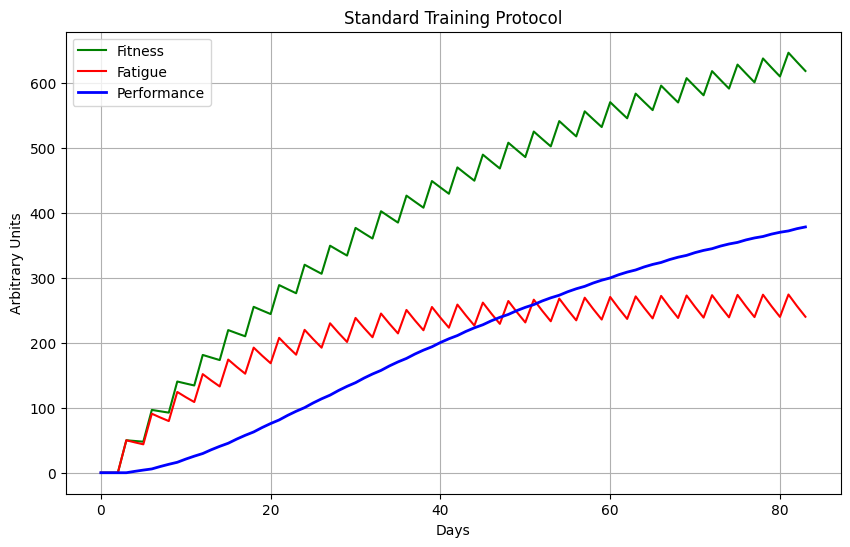

In [4]:
fit_std, fat_std, perf_std = simulate_training_block(days, 45, 15, standard_doses)

plt.figure(figsize=(10, 6))
plt.plot(fit_std, label='Fitness', color='green')
plt.plot(fat_std, label='Fatigue', color='red')
plt.plot(perf_std, label='Performance', color='blue', linewidth=2)
plt.title('Standard Training Protocol')
plt.xlabel('Days')
plt.ylabel('Arbitrary Units')
plt.legend()
plt.grid(True)
plt.show()

# 4. Legal Compliance & References